In [4]:
import subprocess
import sys

def make_greeting(state):
    """read 'name' from the state, write 'greeting'. Return only the field we want to update"""
    name = state['name']
    return {"greeting": f"Hello, {name}!"}
current_state = {"name": "Alice","greeting":""}
update = make_greeting(current_state)
print(update)

{'greeting': 'Hello, Alice!'}


Statement Management   deep dive 

In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class BadListState(TypedDict):
    steps:list


def step1(state:BadListState) -> BadListState:
    currentn = state["steps"]
    new_list = currentn + ["step1"]
    print(new_list)
    return {"steps": new_list}

def step2(state:BadListState) -> BadListState:
    currentn = state["steps"]
    new_list = currentn + ["step2"]
    print(new_list)
    return {"steps": new_list}

builder = StateGraph(BadListState)
builder.add_node("step_one", step1)
builder.add_node("step_two", step2)
builder.add_edge("step_two", END)

builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")


graph = builder.compile()

result = graph.invoke({"steps": []})

print("Final steps:", result["steps"])

['step1']
['step1', 'step2']
Final steps: ['step1', 'step2']


Reducer

In [6]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from operator import add

class GoodLastState(TypedDict):
    steps: Annotated[list, add]


def step1(state:GoodLastState) -> GoodLastState:
    currentn = state["steps"]
    new_list = currentn + ["step1"]
    print(new_list)
    return {"steps": new_list}

def step2(state:GoodLastState) -> GoodLastState:
    currentn = state["steps"]
    new_list = currentn + ["step2"]
    print(new_list)
    return {"steps": new_list}

builder = StateGraph(GoodLastState)
builder.add_node("step_one", step1)
builder.add_node("step_two", step2)
builder.add_edge("step_two", END)

builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")


graph = builder.compile()

result = graph.invoke({"steps": []})

print("Final steps:", result["steps"])



['step1']
['step1', 'step2']
Final steps: ['step1', 'step1', 'step2']


Add message

In [7]:
from typing import TypedDict, Annotated
from  langgraph.graph import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import  HumanMessage, AIMessage



class ChatState(TypedDict):
    messages: Annotated[list, add_messages]
    turn : int


def node_human_input(state:ChatState) ->  ChatState: 
    new_message = HumanMessage(content="What is the weather like today?")
    print(f"[node_human_input] appending : {new_message.content!r}")

    return {
        "messages": [new_message],
        "turn":state["turn"] + 1

    }



def node_ai_response(state:ChatState) ->  ChatState: 
    new_message = AIMessage(content="The weather is sunny and warm.")
    print(f"[node_ai_response] appending : {new_message.content!r}")

    return {
        "messages": [new_message],
        "turn":state["turn"] + 1

    }


builder = StateGraph(ChatState)
builder.add_node("human_input", node_human_input) 
builder.add_node("ai_response", node_ai_response)
builder.add_edge(START, "human_input")
builder.add_edge("human_input", "ai_response") 
builder.add_edge("ai_response", END)

builder = builder.compile()
result = builder.invoke({"messages": [], "turn": 0})
print("Invoking the graph...")
print("Final message list")
for msg in result["messages"]:
    role="human" if isinstance(msg, HumanMessage) else "ai"
    print(f"  {role}: {msg.content!r}")

[node_human_input] appending : 'What is the weather like today?'
[node_ai_response] appending : 'The weather is sunny and warm.'
Invoking the graph...
Final message list
  human: 'What is the weather like today?'
  ai: 'The weather is sunny and warm.'


Graph flow control


Conditional Edge

In [13]:
from typing import TypedDict , Literal
from langgraph.graph import StateGraph, START, END


class  NumberState(TypedDict):
    number: int
    result : str


def receive_number(state:NumberState) -> NumberState:
    num = state["number"]
    return {"number": num, "result": f"Received number: {num}"}


def route_even_or_odd(state:NumberState) -> Literal["even", "odd"]:
    num = state["number"]
    if num % 2 == 0:
        return "even"
    else:
        return "odd"
def odd_node(state:NumberState) -> NumberState:
    msg = f"{state['number']} is odd."
    print(f"[odd_node] {msg}")
    return{"result": msg }
def even_node(state:NumberState) -> NumberState:
    msg = f"{state['number']} is even."
    print(f"[even_node] {msg}")
    return{"result": msg }
    


Defining state

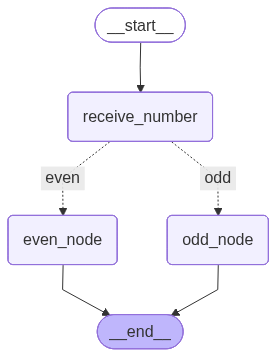

In [14]:
from IPython.display import Image, display
builder = StateGraph(NumberState)
builder.add_node("receive_number", receive_number) 
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)


builder.add_edge(START, "receive_number")
builder.add_conditional_edges(
    "receive_number",
    route_even_or_odd,
    {
        "even": "even_node",
        "odd": "odd_node"
    }
)

builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

Dynamic Routing 

In [ ]:
from typing import TypedDict , Literal
from langgraph.graph import StateGraph, START, END


class TaskState(TypedDict):
    task_type: str
    result : str
    ouput: str


def dispatch(state: TaskState) -> Literal["math_worker", "text_worker", "fallback"]:
    task_type = state["task_type"]
    if task_type == "math":
        return "math_worker"
    elif task_type == "text":
        return "text_worker"
    else:
        return "fallback"
   